# 260918 GITT OCP Stage 1 Comparison

This notebook compares the legacy low-rate anode OCP with a normalized-capacity candidate OCP constructed independently from the v2 and v3 2 h-rest GITT replicates.

The Stage 0 correction, full-cell C/20 qOCV, measured capacity, electrode capacity formulation, $\Delta x$, $\Delta y$, endpoint equations, DFN builder, mesh, solver, temperature, and nominal dynamic parameters follow `260908 Charge Fitting Discharge Validation.ipynb`. Only the negative-electrode OCP source changes between cases.

Stage 2–4 fitting is intentionally excluded.

In [1]:
from pathlib import Path
import platform

import pandas as pd
import pybamm
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
RESULTS_DIR = ROOT / "results" / "260918_gitt_ocp_comparison"
REBUILD = False

print("Python:", platform.python_version())
print("PyBaMM:", pybamm.__version__)
print("Repository:", ROOT)
print("Results:", RESULTS_DIR)

Python: 3.12.14
PyBaMM: 26.8.0.0
Repository: C:\Users\user\Documents\Codex\2026-09-18\https-github-com-rinny-hi-ai2020\work\ai2020_dfn_fitting
Results: C:\Users\user\Documents\Codex\2026-09-18\https-github-com-rinny-hi-ai2020\work\ai2020_dfn_fitting\results\260918_gitt_ocp_comparison


## Rebuild control

In [2]:
required = [
    "gitt_reproducibility.csv",
    "gitt_rest_equilibrium.csv",
    "legacy_vs_new_ocp.csv",
    "stage1_stoichiometry_comparison.csv",
    "dynamic_baseline_comparison.csv",
    "anode_potential_comparison.csv",
    "surface_stoichiometry_coverage.csv",
]

if REBUILD or not all((RESULTS_DIR / name).exists() for name in required):
    from gitt_ocp_analysis import run_analysis
    analysis = run_analysis(ROOT, run_dfn=True)
else:
    print("Using existing verified outputs. Set REBUILD=True to rerun raw extraction and all 12 DFN cases.")

Using existing verified outputs. Set REBUILD=True to rerun raw extraction and all 12 DFN cases.


## 1. Data QC

,replicate,branch,experiment_start,experiment_end,experiment_duration_h,gitt_start,gitt_end,gitt_duration_h,pulse_count,rest_count,median_abs_dVdt_mV_per_min,mean_abs_dVdt_mV_per_min,P90_abs_dVdt_mV_per_min,maximum_abs_dVdt_mV_per_min,normal_pulse_duration_min_median,rest_duration_min_median,cutoff_reached,cutoff_pulse_duration_min
0,v2,lithiation,2026-09-04 19:30:20,2026-09-15 09:34:37,254.07139,2026-09-07 04:45:47,2026-09-15 09:34:37,196.81389,45,46,0.00952,0.01618,0.02013,0.26831,10.0,120.0,True,7.86667
1,v2,delithiation,2026-09-04 19:30:20,2026-09-15 09:34:37,254.07139,2026-09-07 04:45:47,2026-09-15 09:34:37,196.81389,45,45,0.00408,0.01867,0.02302,0.33304,10.0,120.0,True,1.15000
2,v2,all_GITT_rests,2026-09-04 19:30:20,2026-09-15 09:34:37,254.07139,2026-09-07 04:45:47,2026-09-15 09:34:37,196.81389,90,91,0.00883,0.01741,0.02337,0.33304,10.0,120.0,True,1.15000
3,v3,lithiation,2026-09-04 19:30:20,2026-09-15 15:31:16,260.01556,2026-09-07 04:09:26,2026-09-15 15:31:16,203.36389,47,48,0.00853,0.00982,0.01657,0.06056,10.0,120.0,True,4.01667
4,v3,delithiation,2026-09-04 19:30:20,2026-09-15 15:31:16,260.01556,2026-09-07 04:09:26,2026-09-15 15:31:16,203.36389,46,46,0.00863,0.01404,0.01745,0.30602,10.0,120.0,True,7.98333
5,v3,all_GITT_rests,2026-09-04 19:30:20,2026-09-15 15:31:16,260.01556,2026-09-07 04:09:26,2026-09-15 15:31:16,203.36389,93,94,0.00863,0.01188,0.01689,0.30602,10.0,120.0,True,4.01667


,replicate,capacity_type,step_number,capacity_Ah,start_voltage_V,end_voltage_V
0,v2,gitt_lithiation,NaN,0.00179,0.8859,0.0050
1,v2,gitt_delithiation,NaN,0.00176,0.1485,1.5004
2,v2,initial_full_lithiation,2.0,0.00210,1.9499,0.0050
3,v2,initial_full_delithiation,3.0,0.00198,0.1024,1.5000
4,v2,initial_full_lithiation,4.0,0.00178,1.4318,0.0050
5,v2,initial_full_delithiation,5.0,0.00177,0.1137,1.5001
6,v3,gitt_lithiation,NaN,0.00186,0.7396,0.0050
7,v3,gitt_delithiation,NaN,0.00183,0.1496,1.5002
8,v3,initial_full_lithiation,2.0,0.00203,2.8150,0.0050
9,v3,initial_full_delithiation,3.0,0.00194,0.1006,1.5000


,branch,region,q_norm_min,q_norm_max,n_grid,MAE_mV,RMSE_mV,median_abs_difference_mV,maximum_abs_difference_mV,v2_branch_capacity_Ah,v3_branch_capacity_Ah,capacity_difference_pct
0,lithiation,full_overlap,0.000,1.000,1001,4.7951,15.8126,1.0984,153.1000,0.0018,0.0019,3.8356
1,lithiation,normalized_capacity_10_90,0.100,0.899,800,1.6450,2.4826,0.7717,10.3373,0.0018,0.0019,3.8356
2,delithiation,full_overlap,-0.000,1.000,1001,2.2821,6.4932,1.0019,64.4848,0.0018,0.0018,3.8997
3,delithiation,normalized_capacity_10_90,0.101,0.900,800,1.0323,1.7200,0.7474,11.3675,0.0018,0.0018,3.8997
4,mean,full_overlap,0.000,1.000,1001,3.1852,8.6141,0.9976,64.4006,NaN,NaN,NaN
5,mean,normalized_capacity_10_90,0.100,0.900,801,1.3207,2.0557,0.7652,10.8850,NaN,NaN,NaN


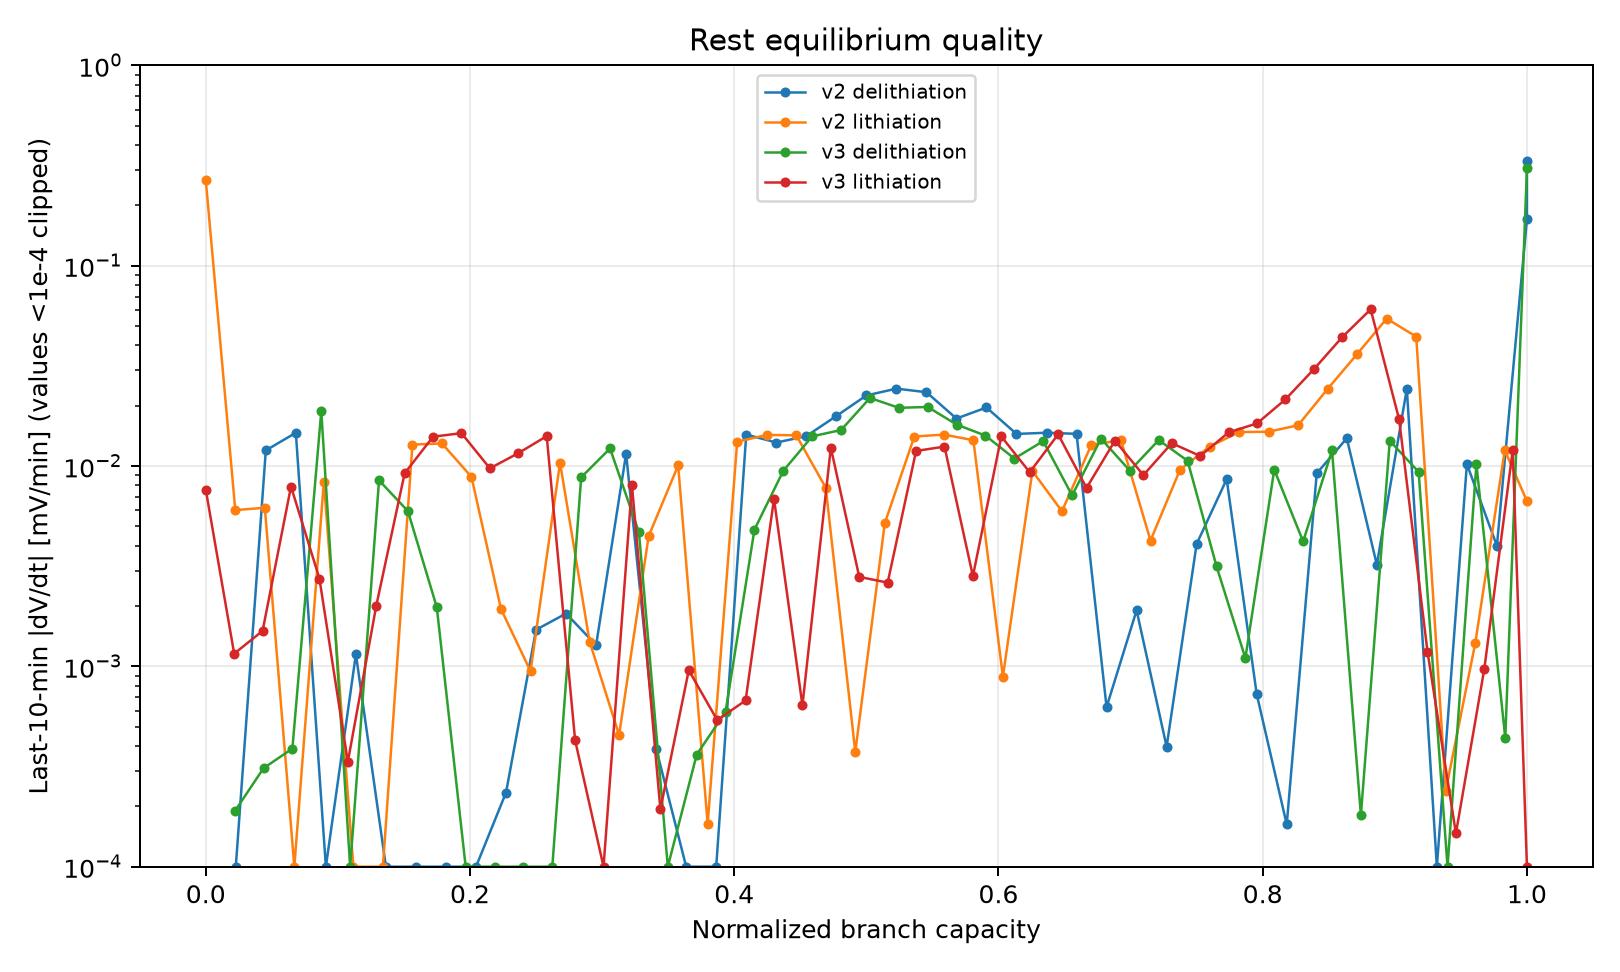

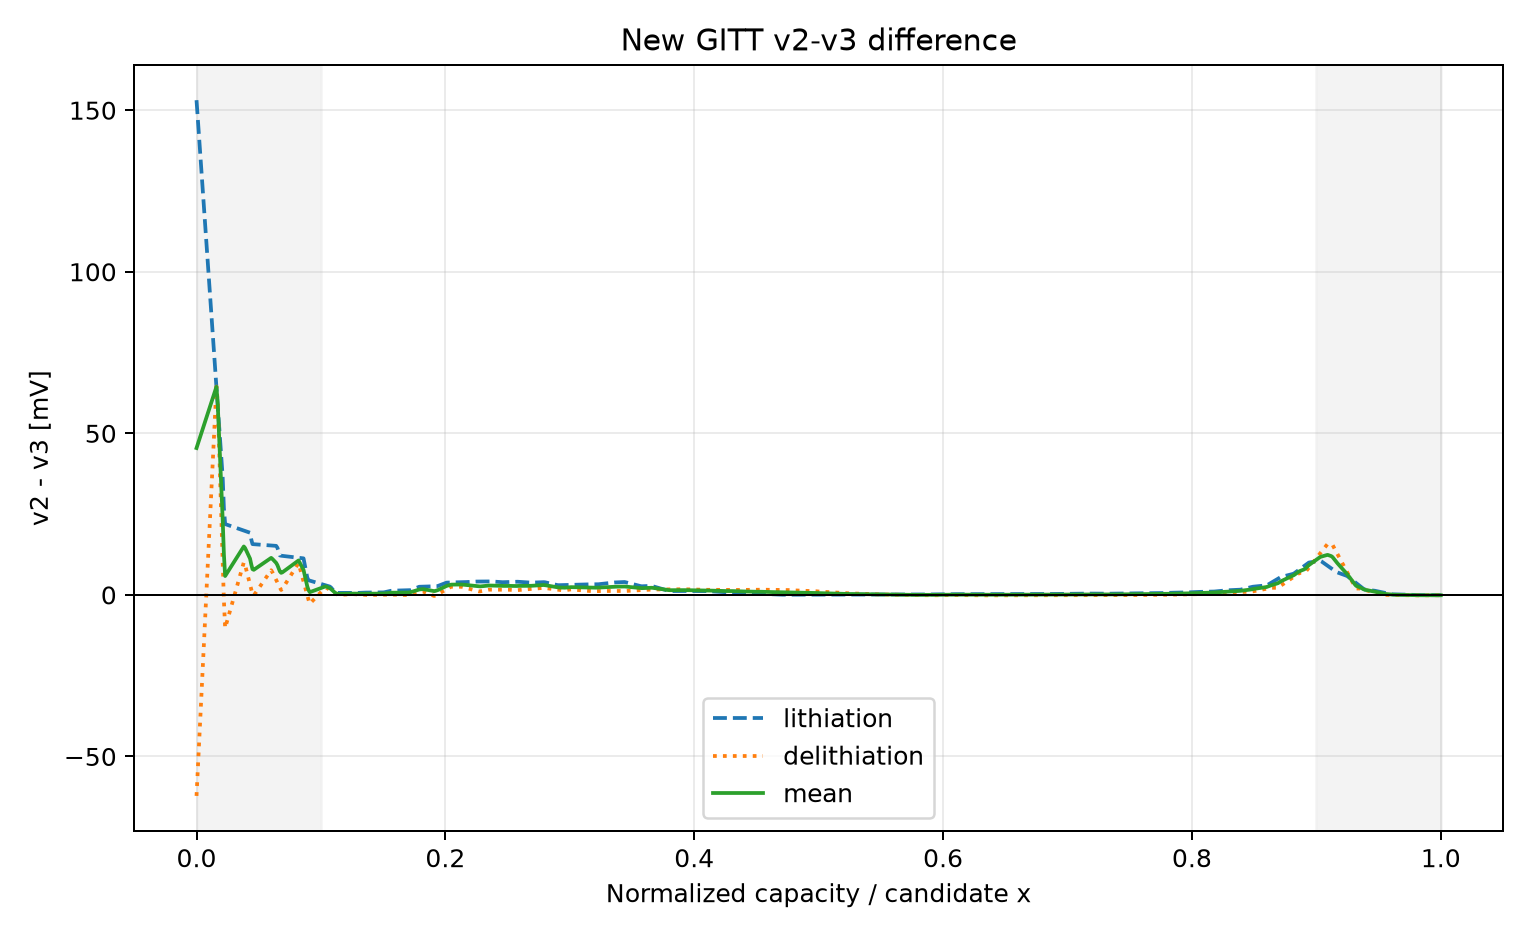

In [3]:
qc = pd.read_csv(RESULTS_DIR / "gitt_data_qc_summary.csv")
capacity = pd.read_csv(RESULTS_DIR / "gitt_capacity_summary.csv")
repro = pd.read_csv(RESULTS_DIR / "gitt_reproducibility.csv")
display(qc.round(5))
display(capacity.round(6))
display(repro.round(4))
display(Image(filename=str(RESULTS_DIR / "gitt_rest_equilibrium.png")))
display(Image(filename=str(RESULTS_DIR / "anode_gitt_v2_v3_reproducibility.png")))

The previous bundle retains aggregated 1 h GITT rest-end points only. It does not contain the final-10-min record traces needed for a like-for-like equilibrium-slope comparison.

## 2. OCP comparison

,replicate,region,mean_lithiation_minus_delithiation_mV,MAE_hysteresis_mV,RMSE_hysteresis_mV,median_abs_hysteresis_mV,maximum_abs_hysteresis_mV
0,v2,full_overlap,-10.4379,10.4379,11.5303,9.4452,21.3815
1,v2,normalized_capacity_10_90,-11.8628,11.8628,12.5558,10.4826,21.3815
2,v3,full_overlap,-13.6610,13.6610,21.7308,10.6158,222.8000
3,v3,normalized_capacity_10_90,-12.5333,12.5333,13.3040,10.8895,22.5395


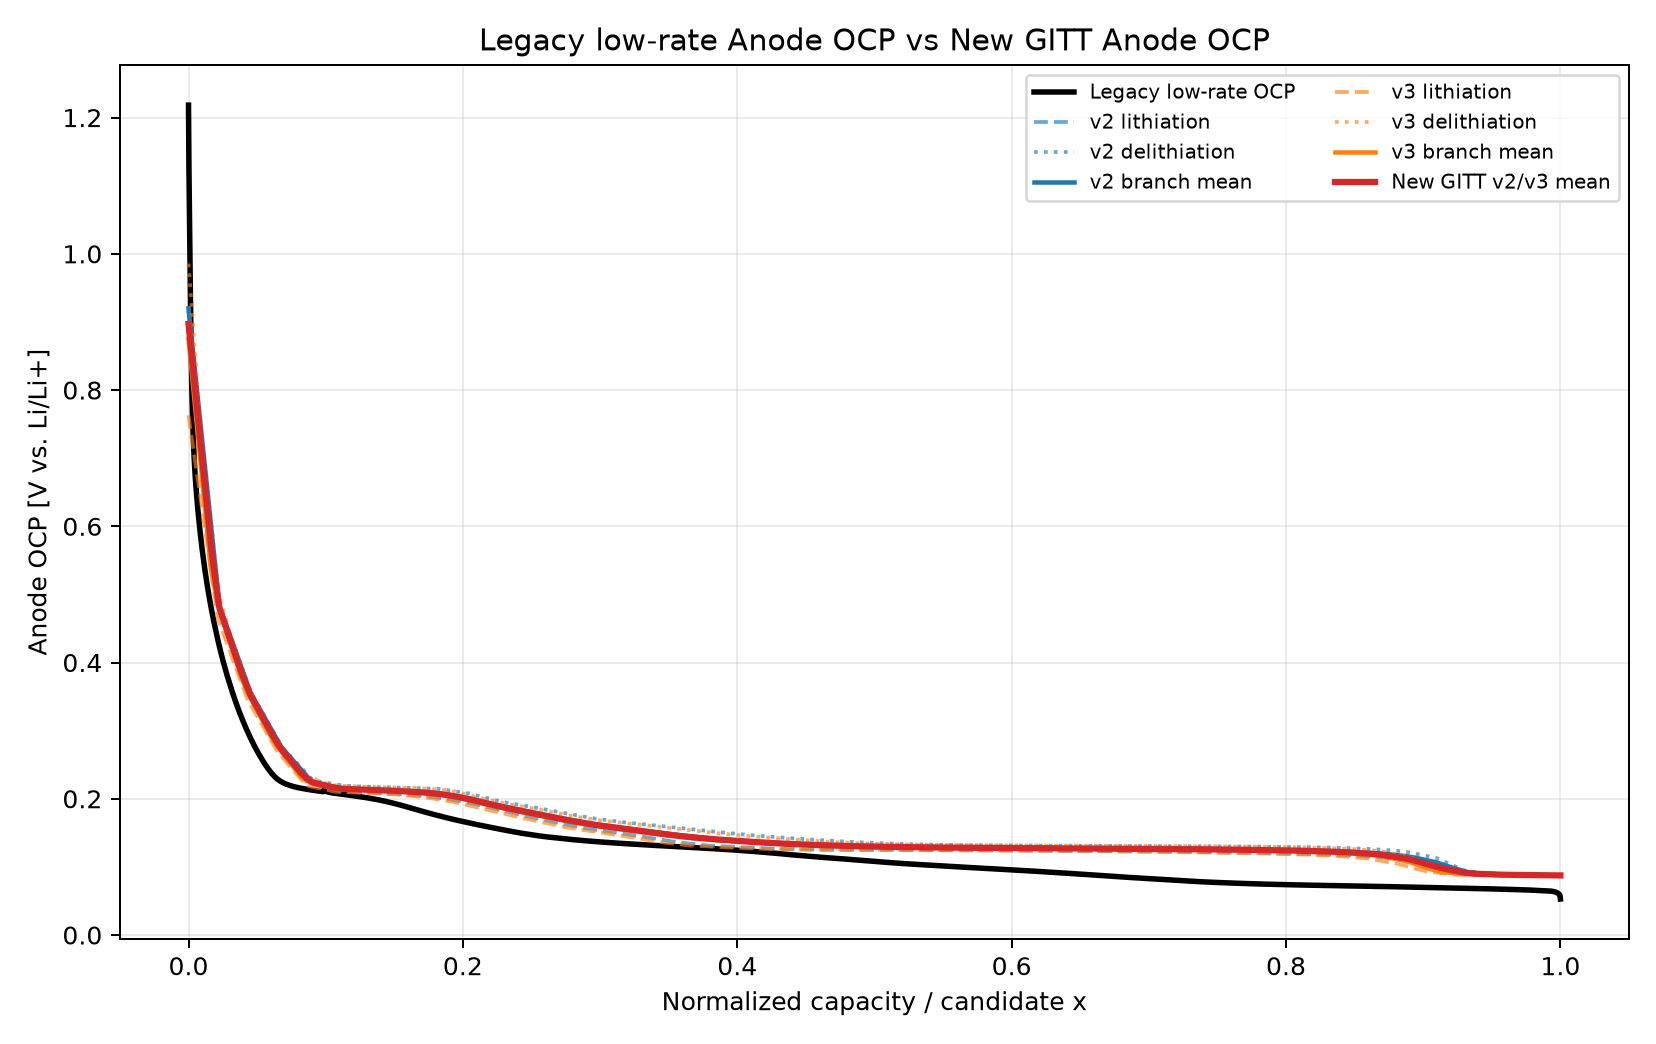

In [4]:
hysteresis = pd.read_csv(RESULTS_DIR / "gitt_branch_hysteresis.csv")
display(hysteresis.round(4))
display(Image(filename=str(RESULTS_DIR / "anode_ocp_legacy_vs_new.png")))

Raw GITT capacity is not treated as absolute stoichiometry. Each branch and replicate is normalized by its own usable capacity before interpolation. The first-pass candidate maps the normalized usable range to candidate x=0..1; that absolute anchor remains unverified.

## 3. Stage 1 comparison

,Case,x0,x100,y100,y0,Delta_x,Delta_y,Q_MEAS_Ah,Qn_Ah,Qp_Ah,...,negative_OCP_measured_max,negative_OCP_model_required_min,negative_OCP_model_required_max,stage1_extrapolated_fraction,stage1_extrapolation_side,physical_bounds_satisfied,optimizer_boundary_hit,optimizer_boundary,Solver_success,Solver_message
0,Legacy,0.001417,0.773635,0.445100,0.953391,0.772219,0.508292,2.337727,3.027286,4.599186,...,0.840542,0.001417,0.773635,0.0,none,True,False,none,True,`gtol` termination condition is satisfied.
1,New GITT,0.000001,0.772220,0.414786,0.923078,0.772219,0.508292,2.337727,3.027286,4.599186,...,1.000000,0.000001,0.772220,0.0,none,True,True,x0_lower,True,`gtol` termination condition is satisfied.


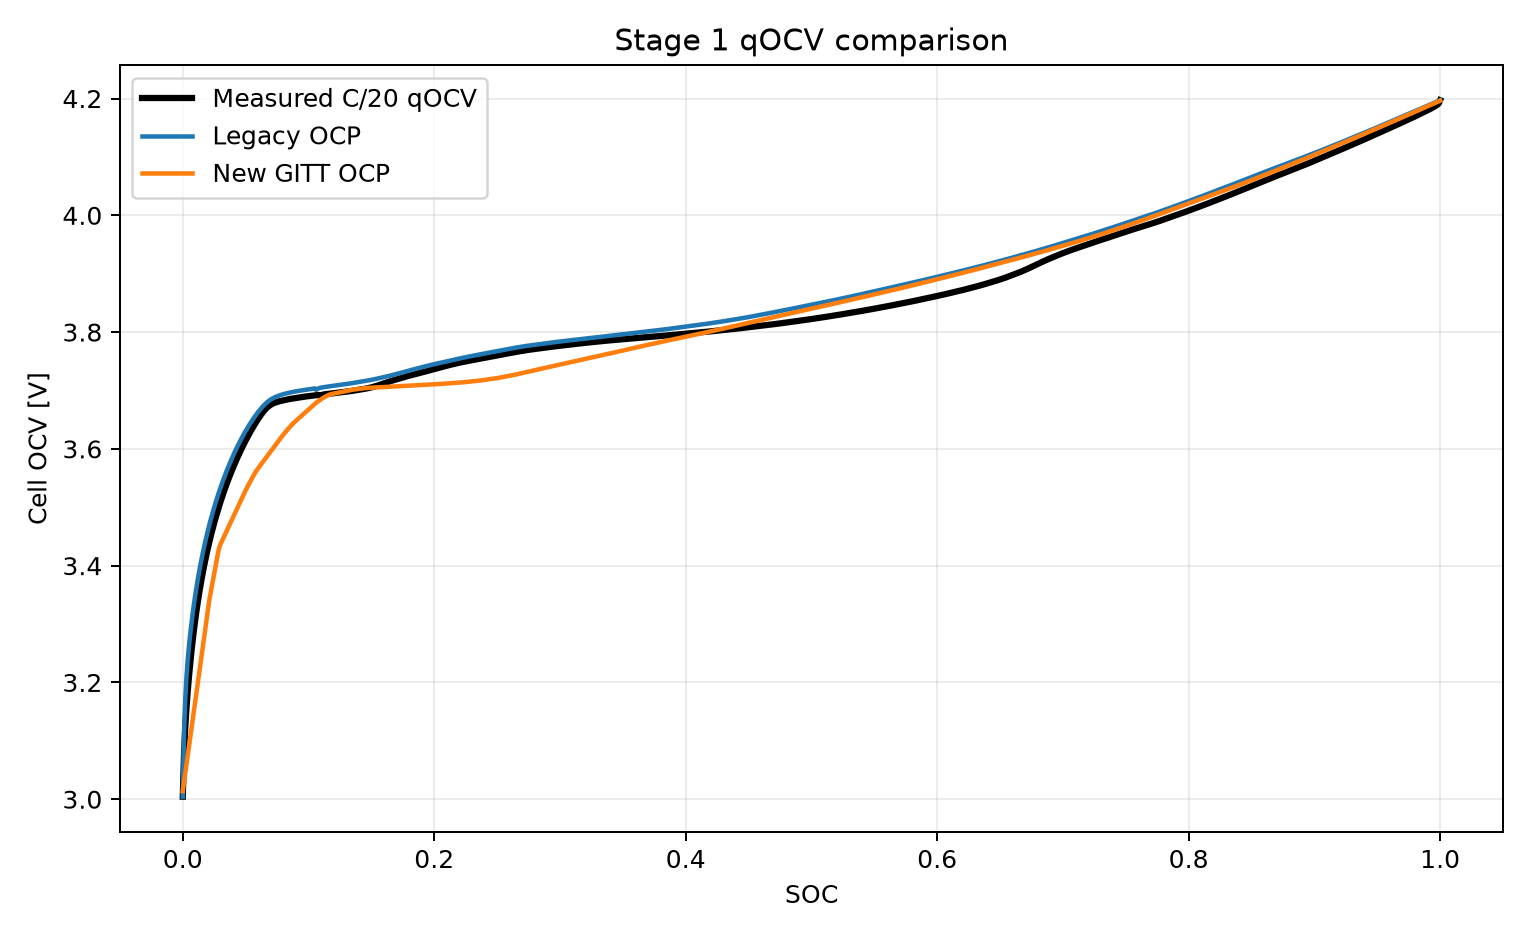

In [5]:
stage1 = pd.read_csv(RESULTS_DIR / "stage1_stoichiometry_comparison.csv")
display(stage1.round(6))
display(Image(filename=str(RESULTS_DIR / "qocv_stage1_comparison.png")))

## 4. Dynamic baseline

,Case,C_rate,direction,overlap_SOC_min,overlap_SOC_max,overlap_point_count,RMSE_full_overlap_mV,MAE_full_overlap_mV,RMSE_SOC_10_90_mV,MAE_SOC_10_90_mV,end_time_error_min,simulation_success,failure_message
0,Legacy,0.5,Charge,0.0000,0.9075,206,43.5835,37.7837,39.9130,36.5648,-0.9437,True,NaN
1,Legacy,0.5,Discharge,0.0087,1.0000,240,61.8232,57.4984,62.2635,60.2550,1.5243,True,NaN
2,Legacy,1.0,Charge,0.0000,0.8162,83,44.9803,34.1899,35.6271,30.3071,0.3788,True,NaN
3,Legacy,1.0,Discharge,0.0252,1.0000,117,68.4805,63.7218,71.8915,69.3605,0.9838,True,NaN
4,Legacy,2.0,Charge,0.0000,0.6497,26,51.6258,33.0169,30.8439,21.3712,0.7929,True,NaN
5,Legacy,2.0,Discharge,0.0561,1.0000,56,54.8204,51.9103,57.4176,55.7930,0.3352,True,NaN
6,New GITT,0.5,Charge,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,False,SolverError: IDAGetDky: IDA_BAD_K: The k-th de...
7,New GITT,0.5,Discharge,0.0170,1.0000,238,45.4162,41.4620,45.2267,43.8994,0.7323,True,NaN
8,New GITT,1.0,Charge,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,False,SolverError: IDAGetDky: IDA_BAD_K: The k-th de...
9,New GITT,1.0,Discharge,0.0252,1.0000,117,54.4843,48.9644,52.3007,51.6365,0.4742,True,NaN


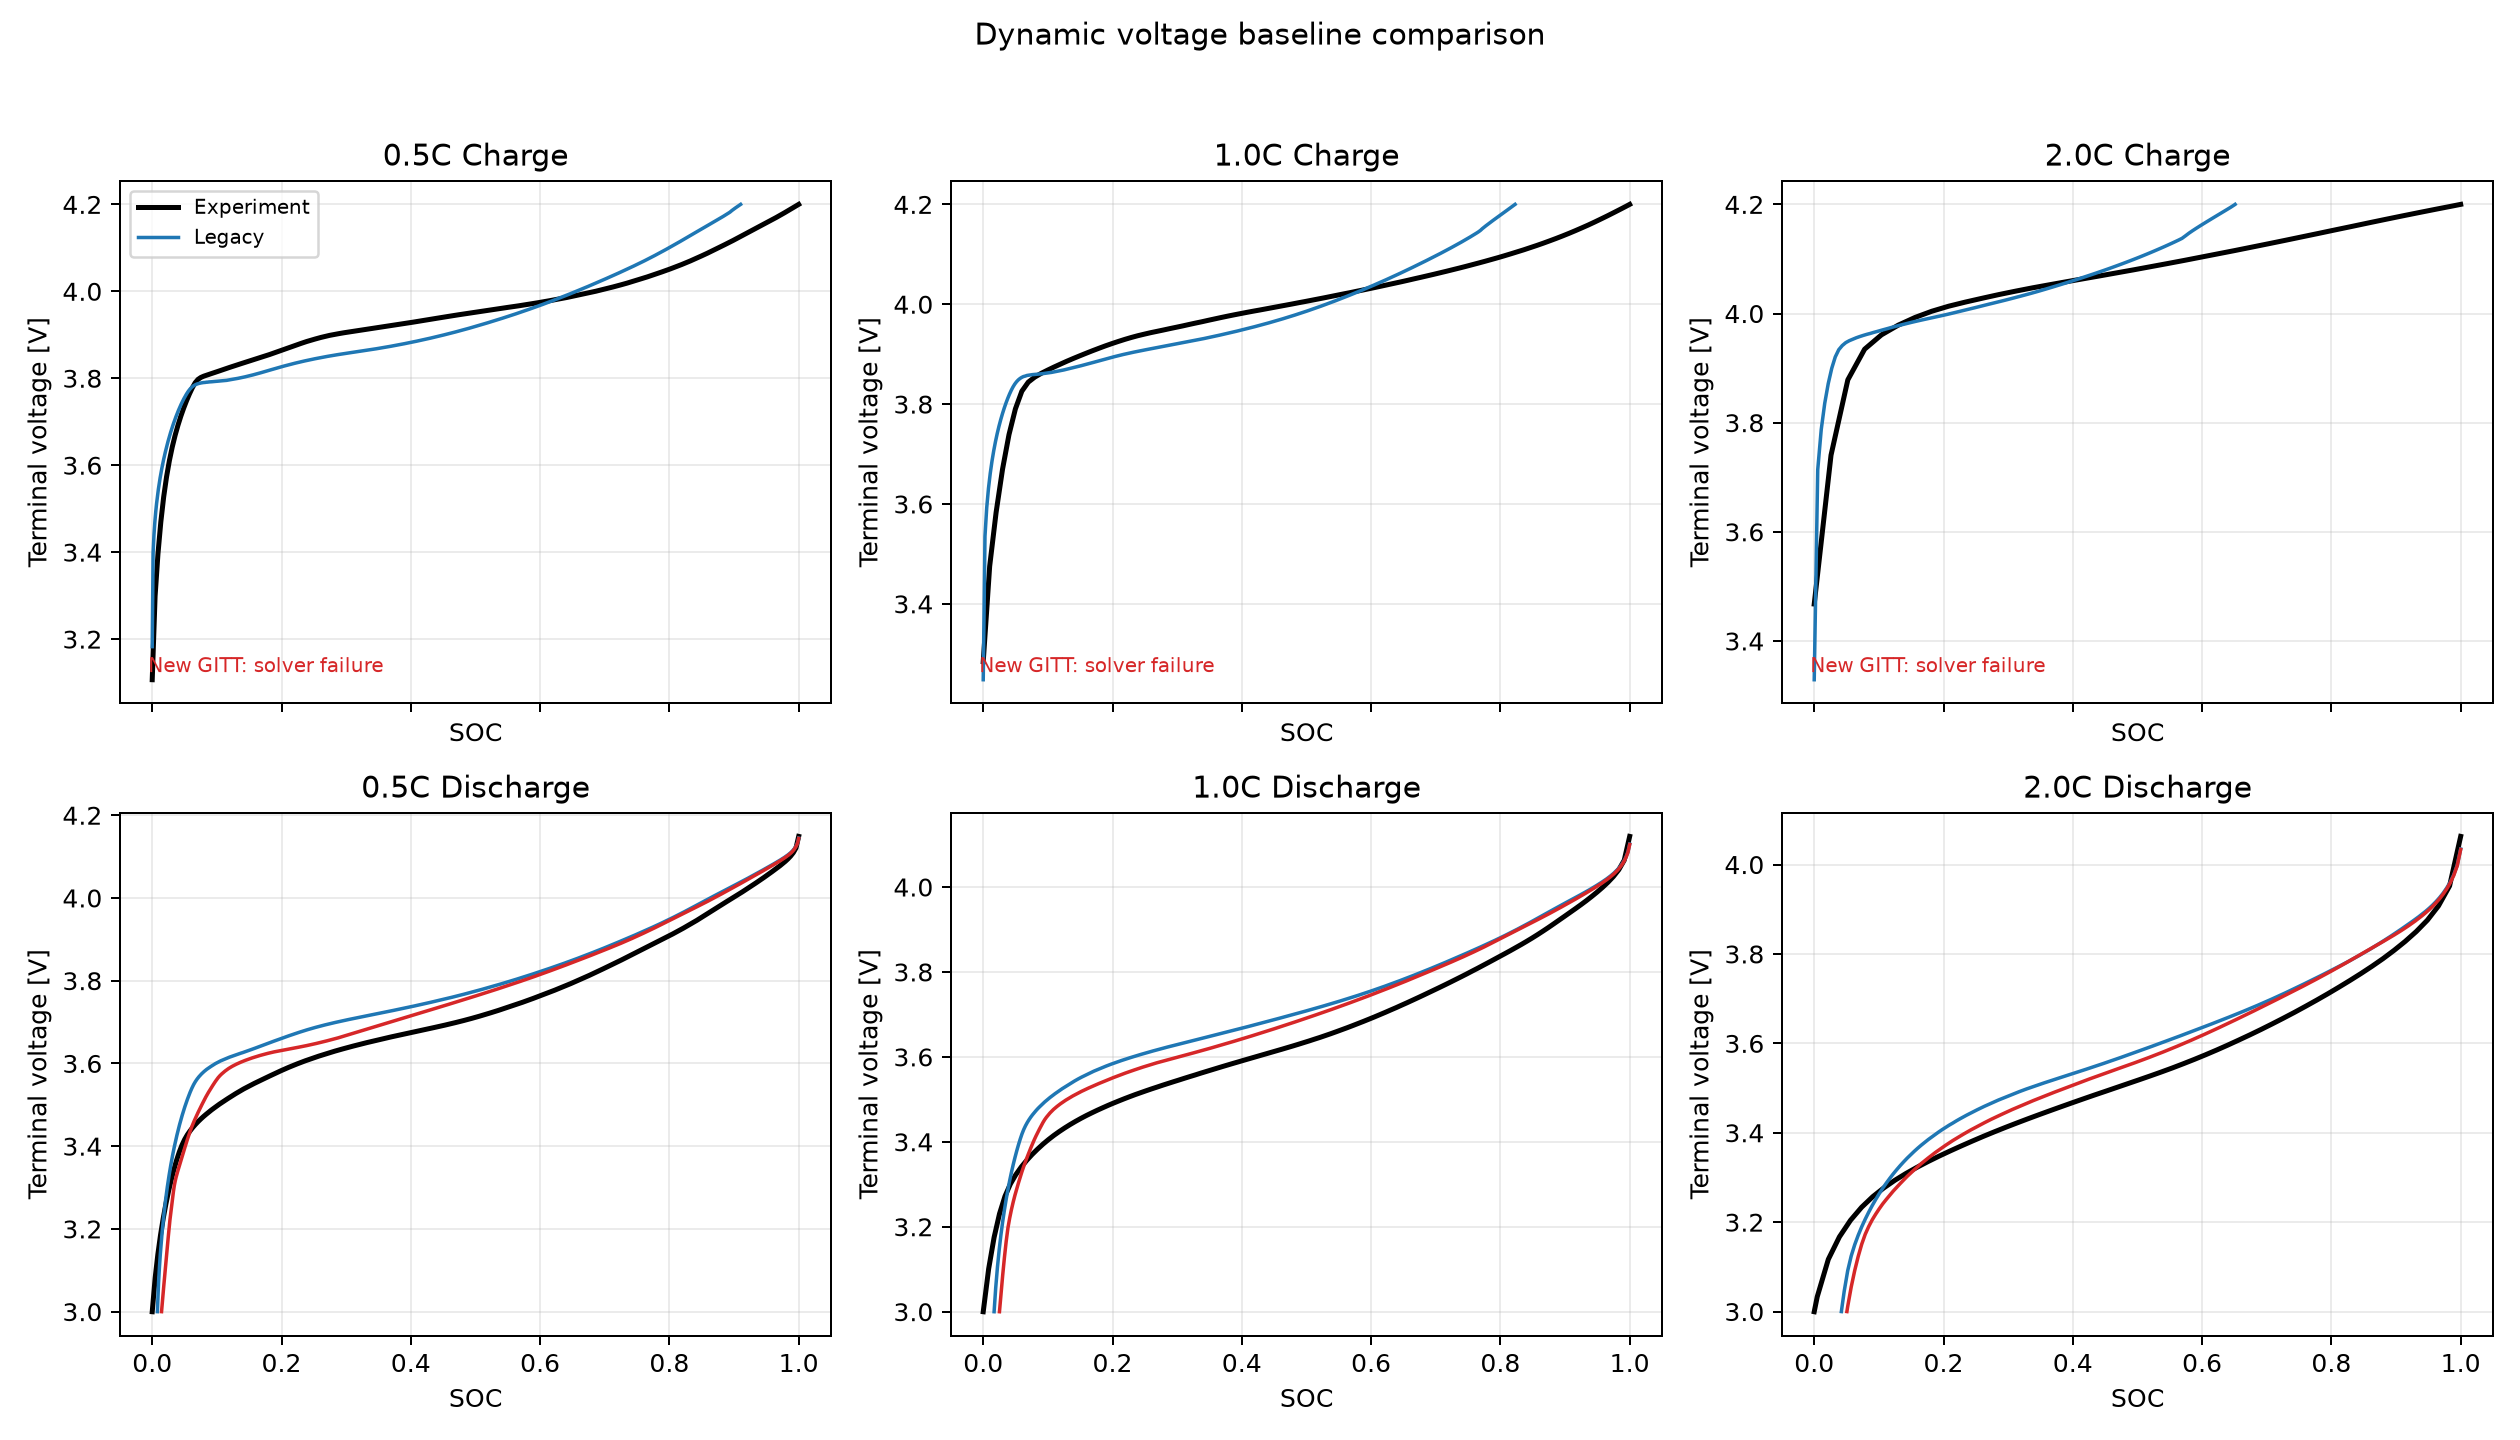

In [6]:
dynamic = pd.read_csv(RESULTS_DIR / "dynamic_baseline_comparison.csv")
display(dynamic.round(4))
display(Image(filename=str(RESULTS_DIR / "dynamic_voltage_baseline_comparison.png")))

## 5. Anode potential and surface stoichiometry coverage

,Case,C_rate,direction,minimum_anode_potential_V,minimum_time_min,minimum_SOC,negative_surface_stoichiometry_at_minimum,anode_potential_below_0V,below_0V_time_fraction,simulation_success,failure_message
0,Legacy,0.5,Charge,0.01841,111.98959,0.91020,0.84188,False,0.00000,True,NaN
1,Legacy,1.0,Charge,-0.02199,50.61216,0.82271,0.84391,True,0.16851,True,NaN
2,Legacy,2.0,Charge,-0.08053,20.02625,0.65106,0.84580,True,0.67959,True,NaN
3,New GITT,0.5,Charge,NaN,NaN,NaN,NaN,False,NaN,False,SolverError: IDAGetDky: IDA_BAD_K: The k-th de...
4,New GITT,1.0,Charge,NaN,NaN,NaN,NaN,False,NaN,False,SolverError: IDAGetDky: IDA_BAD_K: The k-th de...
5,New GITT,2.0,Charge,NaN,NaN,NaN,NaN,False,NaN,False,SolverError: IDAGetDky: IDA_BAD_K: The k-th de...


,Case,C_rate,direction,x_surf_min,x_surf_max,measured_OCP_min,measured_OCP_max,inside_measured_OCP_coverage,measured_upper_limit_excess,measured_lower_limit_shortfall,out_of_range_time_fraction,simulation_success,failure_message
0,Legacy,0.5,Charge,0.00142,0.84188,0.0,0.84054,False,0.00134,0.0,0.01702,True,NaN
1,Legacy,0.5,Discharge,0.00279,0.77364,0.0,0.84054,True,0.00000,0.0,0.00000,True,NaN
2,Legacy,1.0,Charge,0.00142,0.84391,0.0,0.84054,False,0.00337,0.0,0.06314,True,NaN
3,Legacy,1.0,Discharge,0.00404,0.77364,0.0,0.84054,True,0.00000,0.0,0.00000,True,NaN
4,Legacy,2.0,Charge,0.00142,0.84580,0.0,0.84054,False,0.00526,0.0,0.12199,True,NaN
5,Legacy,2.0,Discharge,0.00659,0.77364,0.0,0.84054,True,0.00000,0.0,0.00000,True,NaN
6,New GITT,0.5,Charge,NaN,NaN,0.0,1.00000,False,NaN,NaN,NaN,False,SolverError: IDAGetDky: IDA_BAD_K: The k-th de...
7,New GITT,0.5,Discharge,0.00595,0.77222,0.0,1.00000,True,0.00000,0.0,0.00000,True,NaN
8,New GITT,1.0,Charge,NaN,NaN,0.0,1.00000,False,NaN,NaN,NaN,False,SolverError: IDAGetDky: IDA_BAD_K: The k-th de...
9,New GITT,1.0,Discharge,0.00854,0.77222,0.0,1.00000,True,0.00000,0.0,0.00000,True,NaN


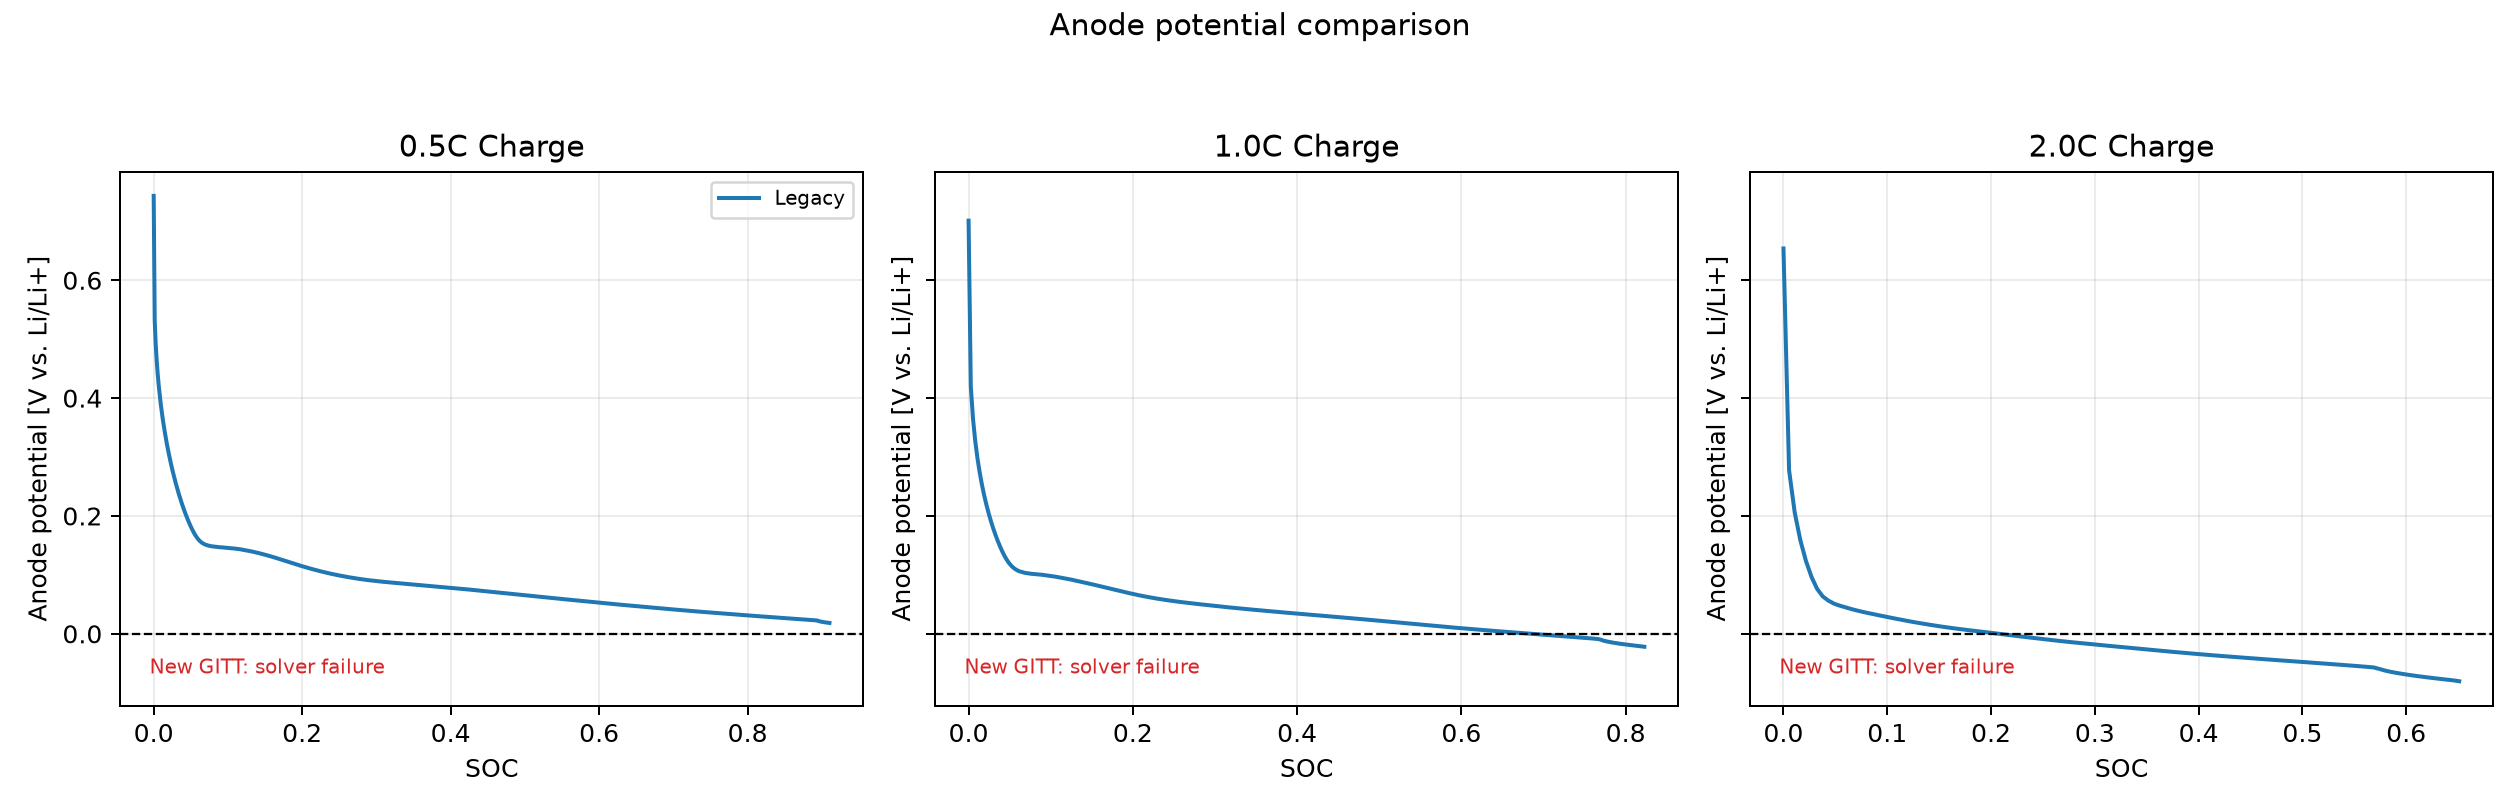

In [7]:
anode = pd.read_csv(RESULTS_DIR / "anode_potential_comparison.csv")
coverage = pd.read_csv(RESULTS_DIR / "surface_stoichiometry_coverage.csv")
display(anode.round(5))
display(coverage.round(5))
display(Image(filename=str(RESULTS_DIR / "anode_potential_comparison.png")))

A modeled anode potential below 0 V is interpreted only as a DFN electrochemical-state/risk indicator, not as proof of lithium plating. New GITT charge metrics are unavailable because the three charge simulations failed at initialization.

## 6. Recommendation

In [8]:
display(Markdown((RESULTS_DIR / "comparison_report.md").read_text(encoding="utf-8")))

# 260918 GITT OCP Stage 1 comparison

## 1. Data QC

- v2: full experiment 254.07 h; GITT section 196.81 h; 90 pulses and 91 two-hour rests. Last-10-min |dV/dt| median/mean/P90/max = 0.0088/0.0174/0.0234/0.3330 mV/min.
- v3: full experiment 260.02 h; GITT section 203.36 h; 93 pulses and 94 two-hour rests. Last-10-min |dV/dt| median/mean/P90/max = 0.0086/0.0119/0.0169/0.3060 mV/min.
- GITT usable capacity: v2 lithiation/delithiation = 1.790/1.760 mAh; v3 = 1.860/1.830 mAh. Replicate differences are 3.84% and 3.90%.
- Replicate mean-OCP difference: full-range MAE/RMSE = 3.19/8.61 mV; 10–90% MAE/RMSE = 1.32/2.06 mV. The full-range maximum is 64.4 mV and is endpoint-driven.
- The legacy bundle contains only aggregated 1 h GITT rest-end points, not the underlying final-10-min record data. A like-for-like 1 h vs 2 h |dV/dt| comparison is therefore not available.

## 2. OCP comparison

- v2 lithiation-delithiation hysteresis over 10–90%: MAE 11.86 mV, RMSE 12.56 mV, maximum 21.38 mV.
- v3 lithiation-delithiation hysteresis over 10–90%: MAE 12.53 mV, RMSE 13.30 mV, maximum 22.54 mV.
- v2 and v3 were normalized by their own usable branch capacity before interpolation and averaging. Raw GITT capacity was not converted directly to absolute stoichiometry.
- For this first-pass candidate, the normalized usable range was mapped to candidate x=0..1. This improves nominal measured coverage but does not establish the absolute stoichiometry anchor.

## 3. Stage 1 comparison

- Legacy: x0/x100 = 0.001417/0.773635; y100/y0 = 0.445100/0.953391; qOCV RMSE full/2–98% = 18.64/18.04 mV.
- New GITT: x0/x100 = 0.000001/0.772220; y100/y0 = 0.414786/0.923078; qOCV RMSE full/2–98% = 32.86/28.73 mV.
- New GITT selected the x0 lower bound and left endpoint errors of 9.40 mV (SOC 0) and -0.81 mV (SOC 100).

## 4. Dynamic baseline

- Legacy completed 6/6 nominal DFN cases.
- New GITT completed 3/3 discharge cases and 0/3 charge cases. All New GITT charge cases failed at initialization with x0 near zero.
- 0.5C discharge full-overlap RMSE: Legacy 61.82 mV; New GITT 45.42 mV.
- 1C discharge full-overlap RMSE: Legacy 68.48 mV; New GITT 54.48 mV.
- 2C discharge full-overlap RMSE: Legacy 54.82 mV; New GITT 44.29 mV.

## 5. Anode potential

- Legacy 0.5C charge: minimum 0.0184 V at SOC 0.910 and 111.99 min; time fraction below 0 V = 0.000.
- Legacy 1C charge: minimum -0.0220 V at SOC 0.823 and 50.61 min; time fraction below 0 V = 0.169.
- Legacy 2C charge: minimum -0.0805 V at SOC 0.651 and 20.03 min; time fraction below 0 V = 0.680.
- New GITT charge anode-potential metrics are unavailable because all charge simulations failed at initialization.
- A modeled anode potential below 0 V is treated only as a DFN electrochemical-state/risk indicator, not proof of lithium plating.

## 6. Recommendation

**Do not adopt yet**

The 2 h GITT experiment has good central-range replicate reproducibility and the New GITT OCP improves the three discharge baseline RMSE values. However, it worsens Stage 1 qOCV error, drives x0 to the lower bound, fails to satisfy the SOC 0 endpoint closely, and makes all nominal charge DFN simulations fail at initialization. The absolute stoichiometry anchor of the normalized capacity axis also remains unverified.

Before Stage 2–4 is considered:

1. establish an independent absolute stoichiometry/capacity anchor for the new half-cells;
2. investigate the low-x endpoint mismatch and endpoint replicate divergence without tuning dynamic parameters;
3. resolve the x0 boundary solution and reproduce all three charge baselines;
4. then reassess surface-stoichiometry coverage and anode potential for New GITT.

Stage 2–4 fitting was not run.